In [20]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from hmmlearn.hmm import GaussianHMM

import vectorbt as vbt

In [21]:
def load_data(symbols=('SPY', '^VIX'), start='2010-01-01', auto_adjust=False):
    """
    Descarga datos de cierre desde yfinance.

    Parámetros
    ----------
    symbols : str, o lista/tuple de str
              Un solo ticker o varios tickers a descargar.
    start   : Fecha de inicio en formato 'YYYY-MM-DD'.

    Retorna
    -------
    pd.DataFrame con una columna por símbolo nombrada por su ticker.
    """
    if isinstance(symbols, str):
        symbols = [symbols]
    else:
        symbols = list(symbols)

    raw_data = yf.download(
        symbols,
        start=start,
        auto_adjust=auto_adjust,
        progress=False
    )

    if raw_data.empty:
        raise ValueError('No se pudieron descargar datos desde yfinance.')

    if isinstance(raw_data.columns, pd.MultiIndex):
        close_data = raw_data['Close']
    else:
        close_data = raw_data

    if isinstance(close_data, pd.Series):
        close_data = close_data.to_frame(name=symbols[0])

    df = close_data[symbols].dropna()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    return df


In [22]:
def compute_features(df, price_col=None, vix_col=None):
    """
    Calcula features técnicas a partir de un DataFrame de precios.

    Parámetros
    ----------
    df        : DataFrame con columnas de precio y, opcionalmente, VIX.
    price_col : Nombre de la columna de precio principal.
                Si None, se usa la primera columna del DataFrame.
    vix_col   : Nombre de la columna VIX.
                Si None, se usa la segunda columna (si existe).

    Retorna
    -------
    (df_enriquecido, features_DataFrame)
    """
    df = df.copy()

    # Auto-detectar columnas si no se especifican
    cols = list(df.columns)
    if price_col is None:
        price_col = cols[0]
    if vix_col is None and len(cols) > 1:
        vix_col = cols[1]

    # Renombrar a nombres estándar internos
    rename = {price_col: 'price'}
    if vix_col and vix_col in df.columns:
        rename[vix_col] = 'vix'
    df = df.rename(columns=rename)

    # Log returns
    df['log_ret'] = np.log(df['price'] / df['price'].shift(1))

    # ATR (simplificado)
    df['atr'] = df['price'].rolling(14).std()

    # SMA diff
    sma10 = df['price'].rolling(10).mean()
    sma30 = df['price'].rolling(30).mean()
    df['sma_diff'] = sma10 - sma30

    # RSI (simple)
    delta = df['price'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))

    df = df.dropna()

    feature_cols = ['log_ret', 'atr', 'sma_diff', 'rsi']
    if 'vix' in df.columns:
        feature_cols = ['log_ret', 'vix', 'atr', 'sma_diff', 'rsi']

    features = df[feature_cols]

    return df, features


In [23]:
class HMMRegimeModel:
    
    def __init__(self, n_states=4):
        self.model = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            n_iter=1000,
            random_state=42
        )
        
    def fit(self, X):
        self.model.fit(X)
        
    def predict(self, X):
        return self.model.predict(X)

In [24]:
def map_states(df, states):
    df = df.copy()
    df['state'] = states
    
    summary = df.groupby('state').agg({
        'log_ret': ['mean', 'std'],
        'vix': 'mean'
    })
    
    print(summary)
    
    return df, summary

In [25]:
def trend_strategy(df):
    sma10 = df['price'].rolling(10).mean()
    sma30 = df['price'].rolling(30).mean()
    
    entries = sma10 > sma30
    exits = sma10 < sma30
    
    return entries, exits

def mean_reversion_strategy(df):
    entries = df['rsi'] < 30
    exits = df['rsi'] > 50
    
    return entries, exits

In [26]:
def apply_hmm_filter(entries, states, allowed_states):
    return entries & states.isin(allowed_states)

In [27]:
def split_data(df, train_size=0.7):
    if not 0 < train_size < 1:
        raise ValueError('train_size debe ser un float entre 0 y 1.')

    split_idx = int(len(df) * train_size)

    if split_idx <= 0 or split_idx >= len(df):
        raise ValueError('La particion generada deja una muestra vacia.')

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    return train_df, test_df

In [28]:
def build_regime_policy(hmm_model, df_with_states):
    """
    Deriva la política de regímenes directamente del modelo ENTRENADO.

    Elimina la necesidad de asignar estados manualmente (e.g. state 0 = bullish)
    sin validar el comportamiento real del modelo, lo cual generaba políticas sin solidez.

    Criterios automáticos
    ---------------------
    - Trend   : log_ret medio > 0 Y VIX medio por debajo de la media global de los estados.
    - Mean Rev: |log_ret medio| por debajo de la mediana Y volatilidad (std) menor a la media global.
    - Los estados no asignados se consideran bajistas/crisis → evitados por ambas estrategias.

    Parámetros
    ----------
    hmm_model      : HMMRegimeModel entrenado.
    df_with_states : DataFrame de entrenamiento con columnas 'state', 'log_ret' y opcionalmente 'vix'.

    Retorna
    -------
    dict {'trend': [estados], 'mean_rev': [estados]}
    """
    agg_dict = {
        'log_ret_mean': ('log_ret', 'mean'),
        'log_ret_std':  ('log_ret', 'std'),
    }
    if 'vix' in df_with_states.columns:
        agg_dict['vix_mean'] = ('vix', 'mean')

    summary = df_with_states.groupby('state').agg(**agg_dict)

    global_ret_std = summary['log_ret_std'].mean()

    # ── Trend: retorno positivo + VIX por debajo de la media (mercado calmo en alza)
    if 'vix_mean' in summary.columns:
        global_vix_mean = summary['vix_mean'].mean()
        trend_mask = (summary['log_ret_mean'] > 0) & (summary['vix_mean'] < global_vix_mean)
    else:
        trend_mask = summary['log_ret_mean'] > 0

    trend_states = summary[trend_mask].index.tolist()

    # ── Mean Reversion: retorno cercano a cero + baja volatilidad (mercado lateral)
    mr_mask = (
        (summary['log_ret_mean'].abs() < summary['log_ret_mean'].abs().median()) &
        (summary['log_ret_std'] < global_ret_std)
    )
    mean_rev_states = [s for s in summary[mr_mask].index.tolist() if s not in trend_states]

    # ── Fallbacks: garantiza al menos un estado por estrategia
    if not trend_states:
        trend_states = [int(summary['log_ret_mean'].idxmax())]
    if not mean_rev_states:
        mean_rev_states = [int(summary['log_ret_mean'].abs().idxmin())]

    policy = {
        'trend':    sorted(trend_states),
        'mean_rev': sorted(mean_rev_states),
    }

    print('── Política derivada automáticamente del modelo entrenado ──────────────')
    print(f'  Trend    → estados {policy["trend"]}')
    print(f'  Mean Rev → estados {policy["mean_rev"]}')
    print()
    print(summary.round(6).to_string())
    print('────────────────────────────────────────────────────────────────────────')

    return policy


In [29]:
def run_baseline(sample_df, init_cash=10_000, price_col=None, vix_col=None):
    """
    Ejecuta trend y mean reversion SIN filtro HMM.
    Sirve como referencia para comparar contra la versión con modelo.
    """
    sample_df, _ = compute_features(sample_df, price_col=price_col, vix_col=vix_col)

    trend_entries, trend_exits = trend_strategy(sample_df)
    mr_entries, mr_exits = mean_reversion_strategy(sample_df)

    trend_pf = vbt.Portfolio.from_signals(
        sample_df['price'],
        entries=trend_entries,
        exits=trend_exits,
        init_cash=init_cash,
        freq='D'
    )

    mr_pf = vbt.Portfolio.from_signals(
        sample_df['price'],
        entries=mr_entries,
        exits=mr_exits,
        init_cash=init_cash,
        freq='D'
    )

    return {'trend_pf': trend_pf, 'mr_pf': mr_pf, 'df': sample_df}


In [30]:
def run_backtest(train_df, test_df=None, n_states=4,
                 regime_policy=None, price_col=None, vix_col=None):
    """
    Entrena el modelo HMM y ejecuta el backtest con filtro de régimen.

    Si regime_policy es None (por defecto), la política se deriva automáticamente
    del modelo entrenado usando build_regime_policy, evitando asignaciones arbitrarias.
    """
    train_df, train_features = compute_features(train_df, price_col=price_col, vix_col=vix_col)

    hmm = HMMRegimeModel(n_states=n_states)
    hmm.fit(train_features.values)

    # ── Derivar política desde el modelo si no se especificó ────────────────
    if regime_policy is None:
        train_states = pd.Series(
            hmm.predict(train_features.values),
            index=train_features.index
        )
        train_df_states = train_df.copy()
        train_df_states['state'] = train_states
        regime_policy = build_regime_policy(hmm, train_df_states)

    def build_portfolios(sample_df):
        sample_df, sample_features = compute_features(
            sample_df, price_col=price_col, vix_col=vix_col
        )
        states = pd.Series(
            hmm.predict(sample_features.values),
            index=sample_features.index
        )

        sample_df = sample_df.loc[sample_features.index].copy()
        sample_df['state'] = states

        trend_entries, trend_exits = trend_strategy(sample_df)
        mr_entries, mr_exits = mean_reversion_strategy(sample_df)

        trend_entries_f = apply_hmm_filter(
            trend_entries, sample_df['state'], regime_policy['trend']
        )
        mr_entries_f = apply_hmm_filter(
            mr_entries, sample_df['state'], regime_policy['mean_rev']
        )

        trend_pf = vbt.Portfolio.from_signals(
            sample_df['price'],
            entries=trend_entries_f,
            exits=trend_exits,
            init_cash=10_000,
            freq='D'
        )

        mr_pf = vbt.Portfolio.from_signals(
            sample_df['price'],
            entries=mr_entries_f,
            exits=mr_exits,
            init_cash=10_000,
            freq='D'
        )

        return {'trend_pf': trend_pf, 'mr_pf': mr_pf, 'df': sample_df}

    results = {
        'in_sample':     build_portfolios(train_df),
        'model':         hmm,
        'regime_policy': regime_policy,
    }

    if test_df is not None:
        results['out_of_sample'] = build_portfolios(test_df)

    return results


In [31]:
DEFAULT_METRICS = [
    'Total Return [%]',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Max Drawdown [%]',
    'Win Rate [%]',
    'Total Trades',
    'Profit Factor',
    'Expectancy',
]

def compare_stats(portfolios, metrics=None):
    """
    Genera una tabla comparativa de métricas para múltiples portfolios.
    Función reutilizable para cualquier conjunto de estrategias vbt.

    Parámetros
    ----------
    portfolios : dict {label: vbt.Portfolio}
    metrics    : list de nombres de métricas de vbt.stats().
                 Si None, usa DEFAULT_METRICS.

    Retorna
    -------
    pd.DataFrame con métricas como filas y estrategias como columnas.
    """
    if metrics is None:
        metrics = DEFAULT_METRICS

    records = {}
    for label, pf in portfolios.items():
        s = pf.stats()
        records[label] = {m: (s[m] if m in s.index else None) for m in metrics}

    return pd.DataFrame(records, index=metrics).round(3)

In [32]:
STATE_COLORS = ["#319ae0", "#42e483", "#b9c73b", "#dd5c4d"]

def plot_regimes(df, title='Regímenes HMM sobre el Precio', figsize=(14, 5)):
    """
    Visualiza el precio con fondo coloreado por régimen HMM.

    Parámetros
    ----------
    df      : DataFrame con columnas 'price' y 'state' y DatetimeIndex.
    title   : Título del gráfico.
    figsize : Tamaño de la figura.
    """
    unique_states = sorted(df['state'].unique())
    colors = {s: STATE_COLORS[i % len(STATE_COLORS)] for i, s in enumerate(unique_states)}

    if 'log_ret' in df.columns and 'vix' in df.columns:
        summary = df.groupby('state').agg({'log_ret': 'mean', 'vix': 'mean'})
        labels = {
            s: f'Estado {s}  |  ret={summary.loc[s, "log_ret"]:.4f}  |  vix={summary.loc[s, "vix"]:.1f}'
            for s in unique_states
        }
    else:
        labels = {s: f'Estado {s}' for s in unique_states}

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df['price'], color='black', linewidth=1, zorder=2)

    states = df['state'].values
    dates  = df.index
    prev   = states[0]
    start  = dates[0]

    for i in range(1, len(states)):
        if states[i] != prev:
            ax.axvspan(start, dates[i], alpha=0.35, color=colors[prev], linewidth=0)
            prev  = states[i]
            start = dates[i]
    ax.axvspan(start, dates[-1], alpha=0.35, color=colors[prev], linewidth=0)

    patches = [
        mpatches.Patch(color=colors[s], alpha=0.7, label=labels[s])
        for s in unique_states
    ]
    price_line = plt.Line2D([0], [0], color='black', linewidth=1, label='Precio')
    ax.legend(handles=[price_line] + patches, loc='upper left', fontsize=8)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio')
    plt.tight_layout()
    plt.show()

In [33]:
FEATURE_NAMES = ['log_ret', 'vix', 'atr', 'sma_diff', 'rsi']

def summarize_hmm_model(hmm_model, feature_names=None):
    """
    Extrae información relevante del modelo HMM entrenado.

    Parámetros
    ----------
    hmm_model    : HMMRegimeModel entrenado.
    feature_names: Lista de nombres de features. Si None usa FEATURE_NAMES.

    Retorna
    -------
    dict con claves:
        'means'       — media por estado (n_states × n_features).
        'stds'        — desv. estándar por estado (n_states × n_features).
        'transitions' — matriz de transición (n_states × n_states).
        'stationary'  — probabilidad estacionaria por estado.
    """
    if feature_names is None:
        feature_names = FEATURE_NAMES

    model = hmm_model.model
    n_states = model.n_components
    state_labels = [f'State {i}' for i in range(n_states)]

    means_df = pd.DataFrame(model.means_, index=state_labels, columns=feature_names)

    stds = np.array([np.sqrt(np.diag(model.covars_[i])) for i in range(n_states)])
    stds_df = pd.DataFrame(stds, index=state_labels, columns=feature_names)

    trans_df = pd.DataFrame(model.transmat_, index=state_labels, columns=state_labels)

    eigvals, eigvecs = np.linalg.eig(model.transmat_.T)
    stat_vec = np.real(eigvecs[:, np.isclose(eigvals, 1.0)])
    stat_vec = (stat_vec / stat_vec.sum()).flatten()
    stationary_s = pd.Series(stat_vec, index=state_labels, name='Stationary Prob')

    return {
        'means':       means_df.round(4),
        'stds':        stds_df.round(4),
        'transitions': trans_df.round(4),
        'stationary':  stationary_s.round(4),
    }


In [34]:
def plot_hmm_model(hmm_model, df_with_states, feature_names=None, figsize=None):
    """
    Visualización completa del modelo HMM entrenado.

    Incluye:
    - Matriz de transición (heatmap).
    - Probabilidades estacionarias por estado.
    - Histograma de cada feature por estado (distribuciones por régimen).

    Parámetros
    ----------
    hmm_model      : HMMRegimeModel entrenado.
    df_with_states : DataFrame con columnas de features y columna 'state'.
    feature_names  : Lista de features a graficar. Si None, usa las disponibles en df.
    figsize        : Tamaño de figura. Si None, se calcula automáticamente.
    """
    if feature_names is None:
        feature_names = [f for f in FEATURE_NAMES if f in df_with_states.columns]

    summary = summarize_hmm_model(hmm_model, feature_names)
    n_states = hmm_model.model.n_components
    state_labels = [f'State {i}' for i in range(n_states)]
    colors = {f'State {i}': STATE_COLORS[i % len(STATE_COLORS)] for i in range(n_states)}

    n_features = len(feature_names)
    if figsize is None:
        figsize = (4 * n_states, 4 + n_features * 2.5)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(n_features + 1, max(n_states, 2), hspace=0.55, wspace=0.4)

    # ── Matriz de transición ──────────────────────────────────────────────────
    ax_trans = fig.add_subplot(gs[0, :n_states // 2 + 1])
    trans = summary['transitions'].values
    im = ax_trans.imshow(trans, cmap='Blues', vmin=0, vmax=1)
    ax_trans.set_xticks(range(n_states))
    ax_trans.set_yticks(range(n_states))
    ax_trans.set_xticklabels(state_labels, fontsize=8)
    ax_trans.set_yticklabels(state_labels, fontsize=8)
    ax_trans.set_title('Matriz de Transición', fontsize=10)
    for i in range(n_states):
        for j in range(n_states):
            ax_trans.text(j, i, f'{trans[i, j]:.2f}', ha='center', va='center',
                          fontsize=8, color='white' if trans[i, j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax_trans, fraction=0.046)

    # ── Probabilidades estacionarias ──────────────────────────────────────────
    ax_stat = fig.add_subplot(gs[0, n_states // 2 + 1:])
    stat = summary['stationary']
    bars = ax_stat.bar(state_labels, stat.values,
                       color=[colors[s] for s in state_labels],
                       edgecolor='black', linewidth=0.5)
    ax_stat.set_title('Probabilidades Estacionarias', fontsize=10)
    ax_stat.set_ylabel('Probabilidad')
    ax_stat.set_ylim(0, max(stat.values) * 1.2)
    for bar, v in zip(bars, stat.values):
        ax_stat.text(bar.get_x() + bar.get_width() / 2,
                     v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

    # ── Distribuciones de features por estado ────────────────────────────────
    for fi, feat in enumerate(feature_names):
        for si in range(n_states):
            ax = fig.add_subplot(gs[fi + 1, si])
            data = df_with_states.loc[df_with_states['state'] == si, feat].dropna()
            ax.hist(data, bins=30, color=colors[f'State {si}'], alpha=0.75, edgecolor='none')
            mean_val = summary['means'].loc[f'State {si}', feat]
            ax.axvline(mean_val, color='black', linewidth=1.5, linestyle='--')
            ax.set_title(f'State {si} — {feat}\nμ={mean_val:.4f}', fontsize=8)
            ax.tick_params(labelsize=7)

    plt.suptitle('Análisis del Modelo HMM — Regímenes y Features', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


In [35]:
def plot_state_feature_heatmap(hmm_summary, normalize='zscore', figsize=(14, 4)):
    """
    Visualiza la relación Estado x Feature con mapa de calor.

    Incluye dos vistas:
    1) Niveles absolutos de medias por estado.
    2) Medias normalizadas para comparativa entre indicadores.

    Parámetros
    ----------
    hmm_summary : Salida de summarize_hmm_model(...)
    normalize   : 'zscore' o 'minmax'
    figsize     : Tamaño de figura
    """
    means = hmm_summary['means'].copy()

    if normalize == 'zscore':
        denom = means.std(axis=0).replace(0, np.nan)
        norm_means = (means - means.mean(axis=0)) / denom
        norm_title = 'Medias Normalizadas (Z-Score por feature)'
        norm_cmap = 'RdYlGn'
    elif normalize == 'minmax':
        denom = (means.max(axis=0) - means.min(axis=0)).replace(0, np.nan)
        norm_means = (means - means.min(axis=0)) / denom
        norm_title = 'Medias Normalizadas (Min-Max por feature)'
        norm_cmap = 'viridis'
    else:
        raise ValueError("normalize debe ser 'zscore' o 'minmax'.")

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Heatmap 1: niveles absolutos
    im0 = axes[0].imshow(means.values, aspect='auto', cmap='Blues')
    axes[0].set_title('Medias por Estado (Nivel Absoluto)', fontsize=10)
    axes[0].set_xticks(range(len(means.columns)))
    axes[0].set_xticklabels(means.columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_yticks(range(len(means.index)))
    axes[0].set_yticklabels(means.index, fontsize=8)
    for i in range(means.shape[0]):
        for j in range(means.shape[1]):
            v = means.values[i, j]
            axes[0].text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=7,
                         color='white' if v > np.nanmean(means.values) else 'black')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    # Heatmap 2: comparativa normalizada
    im1 = axes[1].imshow(norm_means.values, aspect='auto', cmap=norm_cmap)
    axes[1].set_title(norm_title, fontsize=10)
    axes[1].set_xticks(range(len(norm_means.columns)))
    axes[1].set_xticklabels(norm_means.columns, rotation=45, ha='right', fontsize=8)
    axes[1].set_yticks(range(len(norm_means.index)))
    axes[1].set_yticklabels(norm_means.index, fontsize=8)
    for i in range(norm_means.shape[0]):
        for j in range(norm_means.shape[1]):
            v = norm_means.values[i, j]
            if np.isnan(v):
                txt = 'nan'
                color = 'black'
            else:
                txt = f'{v:.2f}'
                color = 'white' if abs(v) > 0.8 else 'black'
            axes[1].text(j, i, txt, ha='center', va='center', fontsize=7, color=color)
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    plt.suptitle('Relación Estados vs Features', fontsize=13)
    plt.tight_layout()
    plt.show()


── Política derivada automáticamente del modelo entrenado ──────────────
  Trend    → estados [0, 1, 3]
  Mean Rev → estados [2]

       log_ret_mean  log_ret_std   vix_mean
state                                      
0          0.000232     0.010513  18.649465
1          0.001111     0.005637  15.339899
2         -0.000125     0.018974  27.952958
3          0.000490     0.005480  12.838793
────────────────────────────────────────────────────────────────────────
=== Medias por estado ===


,log_ret,vix,atr,sma_diff,rsi
State 0,0.0002,18.6882,2.3139,-1.1334,45.2262
State 1,0.0011,15.3293,2.2484,3.3278,71.8031
State 2,-0.0001,27.9750,5.7233,0.0066,51.2668
State 3,0.0005,12.8377,1.2819,1.4871,57.0794


=== Desviaciones estándar por estado ===


,log_ret,vix,atr,sma_diff,rsi
State 0,0.0111,3.5345,0.7813,1.8100,11.2190
State 1,0.0067,2.7051,1.0449,1.6806,10.6450
State 2,0.0194,9.4089,3.7900,9.3486,16.8035
State 3,0.0066,1.8872,0.4430,1.3999,11.8865


=== Matriz de transición ===


,State 0,State 1,State 2,State 3
State 0,0.9400,0.0423,0.0110,0.0067
State 1,0.0142,0.9487,0.0041,0.0330
State 2,0.0137,0.0024,0.9839,0.0000
State 3,0.0244,0.0141,0.0000,0.9615


=== Probabilidades estacionarias ===


,Stationary Prob
State 0,0.2276
State 1,0.2732
State 2,0.2255
State 3,0.2738


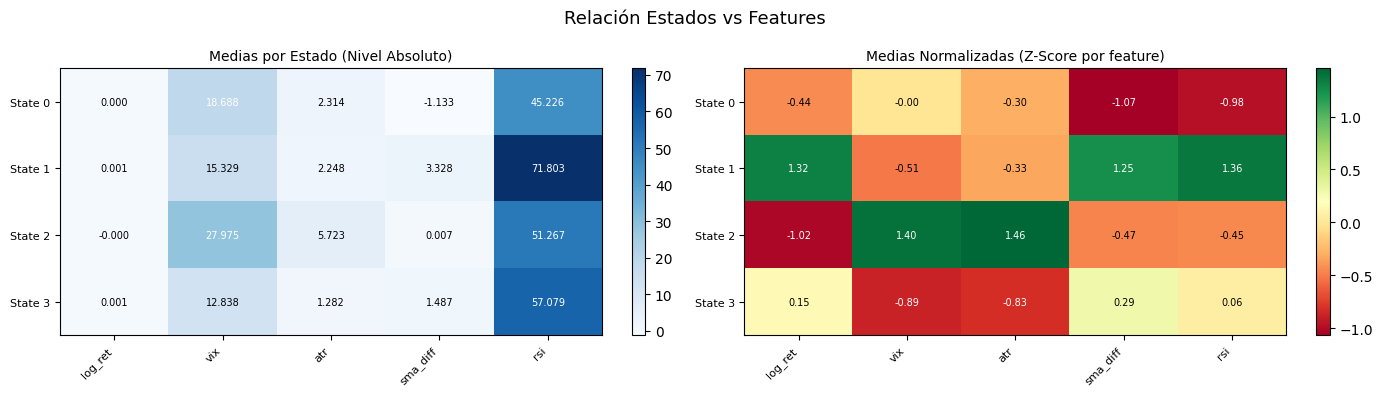

/tmp/ipykernel_8328/399356434.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


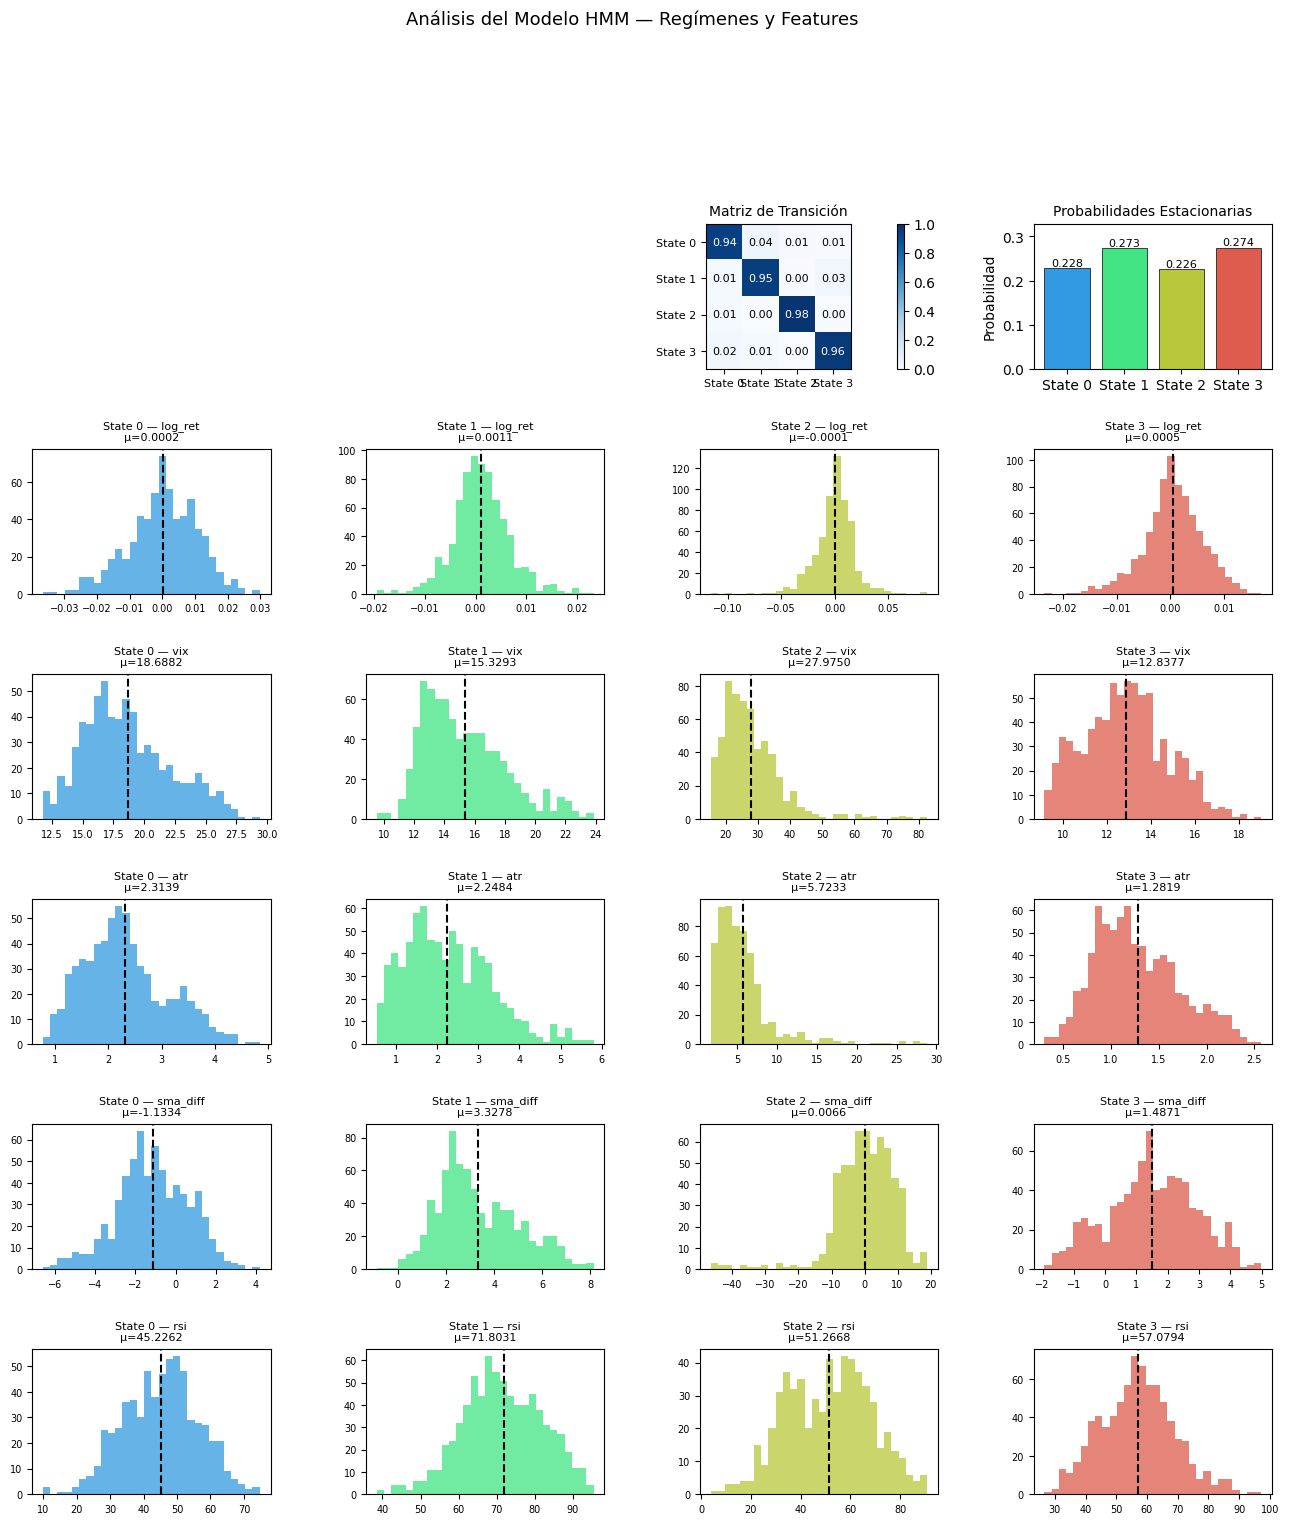

,Trend Baseline IS,Trend HMM IS,Trend Baseline OOS,Trend HMM OOS,MR Baseline IS,MR HMM IS,MR Baseline OOS,MR HMM OOS
Total Return [%],63.675,46.635,35.957,9.908,65.123,13.827,15.507,17.448
Sharpe Ratio,0.560,0.540,0.783,0.473,0.539,0.195,0.391,0.429
Sortino Ratio,0.752,0.735,1.121,0.660,0.761,0.271,0.597,0.657
Max Drawdown [%],17.510,16.620,18.607,6.961,30.181,30.820,13.239,13.239
Win Rate [%],44.444,47.222,47.059,50.000,81.818,71.429,68.750,75.000
Total Trades,46.000,36.000,17.000,8.000,33.000,14.000,17.000,17.000
Profit Factor,1.897,1.972,2.814,2.232,2.443,1.439,2.213,2.368
Expectancy,126.616,129.542,211.510,123.854,197.342,98.768,128.043,140.698


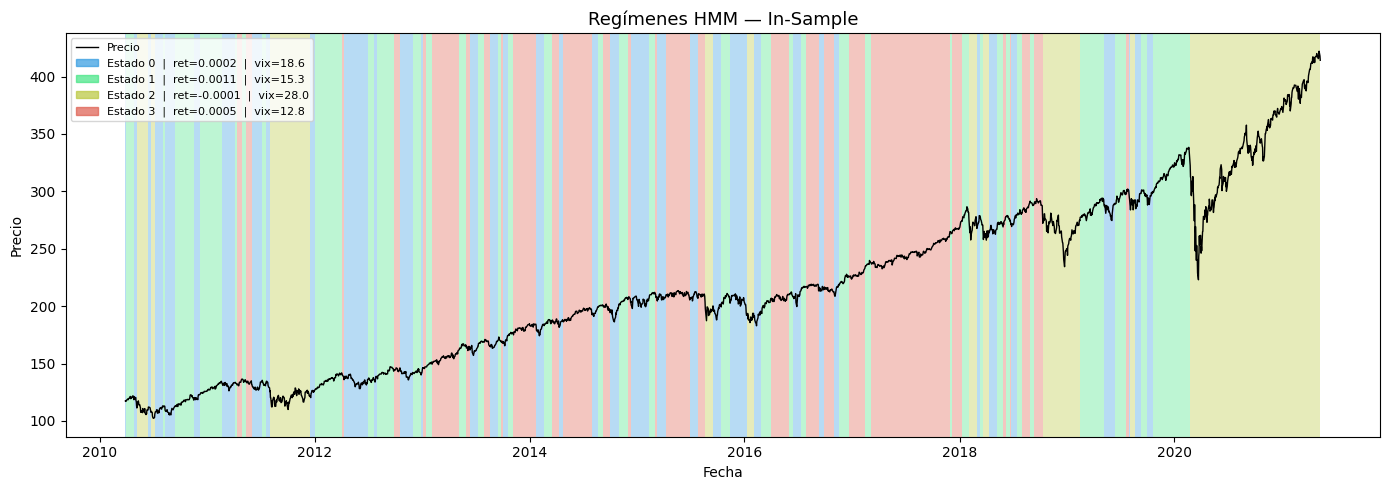

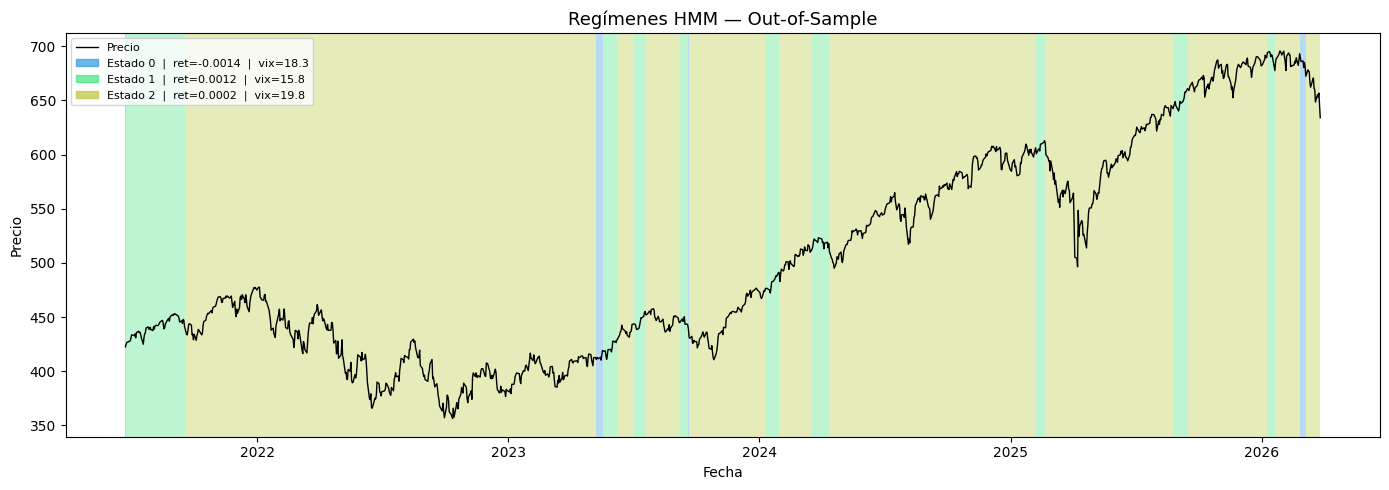

In [36]:
# ── Configuración de símbolos ─────────────────────────────────────────────────
PRICE_COL = 'SPY'
VIX_COL   = '^VIX'

# ── Carga y partición ─────────────────────────────────────────────────────────
df = load_data(symbols=(PRICE_COL, VIX_COL))       # columns: 'SPY', '^VIX'
train_df, test_df = split_data(df, train_size=0.7)

# ── Baseline (sin HMM) ────────────────────────────────────────────────────────
baseline_is  = run_baseline(train_df, price_col=PRICE_COL, vix_col=VIX_COL)
baseline_oos = run_baseline(test_df,  price_col=PRICE_COL, vix_col=VIX_COL)

# ── HMM Backtest — política derivada automáticamente del modelo ───────────────
results = run_backtest(
    train_df=train_df, test_df=test_df,
    price_col=PRICE_COL, vix_col=VIX_COL
)

# ── Análisis del modelo HMM entrenado ─────────────────────────────────────────
feature_names = [f for f in FEATURE_NAMES if f in results['in_sample']['df'].columns]
hmm_summary   = summarize_hmm_model(results['model'], feature_names)

print('=== Medias por estado ===')
display(hmm_summary['means'])
print('=== Desviaciones estándar por estado ===')
display(hmm_summary['stds'])
print('=== Matriz de transición ===')
display(hmm_summary['transitions'])
print('=== Probabilidades estacionarias ===')
display(hmm_summary['stationary'].to_frame())

# Relación estados-features con heatmap (niveles y comparativa normalizada)
plot_state_feature_heatmap(hmm_summary, normalize='zscore')

plot_hmm_model(results['model'], results['in_sample']['df'], feature_names)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
portfolios = {
    'Trend  Baseline IS':  baseline_is['trend_pf'],
    'Trend  HMM IS':       results['in_sample']['trend_pf'],
    'Trend  Baseline OOS': baseline_oos['trend_pf'],
    'Trend  HMM OOS':      results['out_of_sample']['trend_pf'],
    'MR  Baseline IS':     baseline_is['mr_pf'],
    'MR  HMM IS':          results['in_sample']['mr_pf'],
    'MR  Baseline OOS':    baseline_oos['mr_pf'],
    'MR  HMM OOS':         results['out_of_sample']['mr_pf'],
}

stats_table = compare_stats(portfolios)
display(stats_table)

# ── Visualización de regímenes ────────────────────────────────────────────────
plot_regimes(results['in_sample']['df'],     title='Regímenes HMM — In-Sample')
plot_regimes(results['out_of_sample']['df'], title='Regímenes HMM — Out-of-Sample')
